# Step 1c — Optical flood reference

Spec: `CLAUDE.md` §6 step 1c, union revision of 2026-09-16. **Sentinel-2 only. No Sentinel-1 data
is used anywhere in this notebook**, because every ready-made SAR flood product for this event is
derived from Sentinel-1 and would make the Step 2 validation circular.

1. **Acquisition table** (a standalone exhibit result): every Sentinel-2 acquisition over the study
   area, 11–25 March 2023, with clear-pixel fractions for the study area, the Pajaro + northern
   Salinas valleys, and the lower Pajaro Valley.
2. **Water mask per date** for 15, 20 and 25 March: NDWI = (B3 − B8)/(B3 + B8) and
   MNDWI = (B3 − B11)/(B3 + B11) against a pre-event baseline (1 Feb – 8 Mar 2023), permanent water
   (`JRC/GSW1_4/GlobalSurfaceWater` occurrence > 50) removed.
3. **The reference is the union of the three dates**, reported as three nested extents — seen on
   15 March, added by 20 March, added by 25 March — never as one number, with the cloud-covered
   share of each addition, because recession and cloud gaps both create additions.
4. **Threshold sensitivity**: mapped area with NDWI/MNDWI minima at 0 and 0.1, MNDWI rise at 0.15,
   0.2 and 0.25, and minimum polygon size at 0.1, 0.2 and 0.5 ha.
5. **Figure**: pre-event composite, the 15 and 25 March composites, and the union mask coloured by
   the date first seen.

15 March is the closest thing to peak extent (4 days after); the 25 March additions are more likely
long-standing water or irrigation than flood.

Limitations (`CLAUDE.md` §8): no optical observation exists for 11–14 March, when water was at its
peak, so this reference **under-counts** flooded area, which biases against the method rather than
for it; and it is a mask derived here, not a surveyed extent, so it carries its own error.

Aggregate figures for sanity checks are in `docs/ground_truth_aggregate.md`; January and March 2023
are kept strictly separate. This notebook **overwrites the Step 1c outputs** on each run; the
earlier single-date version is in git history at commit 7424591.

**CHECKPOINT:** the figure, the acquisition table and the threshold sensitivity. Stop before Step 2.

In [1]:
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

import common as C
from maps import HALO, add_north_arrow, add_scale_bar, ee_tif

ee.Initialize(project=C.EE_PROJECT)

PEAK = pd.Timestamp("2023-03-11")            # night of 10-11 March 2023
POST_WINDOW = ("2023-03-11", "2023-03-26")   # 11-25 March 2023 inclusive
PRE_WINDOW = ("2023-02-01", "2023-03-09")    # 1 Feb - 8 Mar 2023 inclusive
DATES = ["2023-03-15", "2023-03-20", "2023-03-25"]
SEEN_COLOR = {"2023-03-15": "red", "2023-03-20": "orange", "2023-03-25": "gold"}
AOI_LL = (-121.90, 36.60, -121.55, 36.98)    # Pajaro Valley to northern Salinas Valley
PAJARO_LL = (-121.86, 36.84, -121.70, 36.95)  # lower Pajaro Valley, the breach area
ACRE_M2 = 4046.8564224

counties_fc = ee.FeatureCollection(C.COUNTIES).filter(ee.Filter.inList("GEOID", C.COUNTY_GEOIDS))
region = counties_fc.geometry()
aoi, pajaro_aoi = ee.Geometry.BBox(*AOI_LL), ee.Geometry.BBox(*PAJARO_LL)
counties = gpd.GeoDataFrame.from_features(counties_fc.getInfo()["features"], crs="EPSG:4326")
counties = counties[["GEOID", "NAME", "geometry"]].sort_values("GEOID").reset_index(drop=True)
counties_m = counties.to_crs(C.GRID_CRS)
towns = gpd.GeoDataFrame({"name": list(C.TOWNS)}, crs="EPSG:4326",
                         geometry=gpd.points_from_xy(*zip(*C.TOWNS.values()))).to_crs(C.GRID_CRS)
units = gpd.read_file(C.DERIVED / "01_units_dwr.geojson")
units = units[units.is_unit.astype(bool)]
N_UNITS = len(units)


def stamp(window):
    print(f"n units = {N_UNITS} | date window: {window} | datasets: {C.S2}, {C.S2_CLOUD} "
          f"(cs_cdf > {C.CLEAR_CS_CDF}), {C.GSW}")


def clear_s2(start, end):
    # Sentinel-2 SR over the study area, Cloud Score+ linked, cloudy pixels masked
    return (ee.ImageCollection(C.S2).filterBounds(region).filterDate(start, end)
            .linkCollection(ee.ImageCollection(C.S2_CLOUD), ["cs_cdf"])
            .map(lambda im: im.updateMask(im.select("cs_cdf").gt(C.CLEAR_CS_CDF))))


def next_day(d):
    return ee.Date(d).advance(1, "day").format("YYYY-MM-dd").getInfo()


def acres(img_mask, geom=None):
    total = (ee.Image.pixelArea().updateMask(img_mask)
             .reduceRegion(ee.Reducer.sum(), geom or region, scale=20, maxPixels=1e10, tileScale=4)
             .get("area").getInfo())
    return (total or 0) / ACRE_M2


print("Sentinel-1 is not used in this notebook.")
print(f"dates used for the union: {', '.join(DATES)} | pre-event baseline {PRE_WINDOW[0]} to 2023-03-08 | "
      f"n units = {N_UNITS}")

Sentinel-1 is not used in this notebook.
dates used for the union: 2023-03-15, 2023-03-20, 2023-03-25 | pre-event baseline 2023-02-01 to 2023-03-08 | n units = 1320


## 1. Acquisition table — clear-pixel fraction by date (exhibit result)

In [2]:
post_raw = (ee.ImageCollection(C.S2).filterBounds(region).filterDate(*POST_WINDOW)
            .linkCollection(ee.ImageCollection(C.S2_CLOUD), ["cs_cdf"]))


def scene_row(im):
    clear = im.select("cs_cdf").gt(C.CLEAR_CS_CDF)
    frac = clear.reduceRegion(ee.Reducer.mean(), im.geometry().intersection(region, 100),
                              scale=200, maxPixels=1e9, bestEffort=True).get("cs_cdf")
    return ee.Feature(None, {"date": im.date().format("YYYY-MM-dd"), "tile": im.get("MGRS_TILE"),
                             "scene_cloud_pct": im.get("CLOUDY_PIXEL_PERCENTAGE"),
                             "clear_frac_scene": frac})


scenes = pd.DataFrame([f["properties"] for f in post_raw.map(scene_row).getInfo()["features"]])
scenes["clear_frac_scene"] = scenes.clear_frac_scene.astype(float).round(3)
scenes["scene_cloud_pct"] = scenes.scene_cloud_pct.astype(float).round(1)
print("Scenes intersecting the two counties:")
print(scenes.sort_values(["date", "tile"]).to_string(index=False))


def clear_mosaic(d):
    day = post_raw.filterDate(d, ee.Date(d).advance(1, "day"))
    return day.map(lambda im: im.select("cs_cdf").gt(C.CLEAR_CS_CDF)).mosaic().unmask(0)


rows = []
for d in sorted(scenes.date.unique()):
    cm = clear_mosaic(d)
    r = {"date": d, "days_after_peak": (pd.Timestamp(d) - PEAK).days,
         "scenes": int(post_raw.filterDate(d, ee.Date(d).advance(1, "day")).size().getInfo())}
    for name, geom in [("clear_frac_study_area", region), ("clear_frac_valleys", aoi),
                       ("clear_frac_lower_pajaro", pajaro_aoi)]:
        r[name] = round(float(cm.reduceRegion(ee.Reducer.mean(), geom, scale=100, maxPixels=1e9,
                                              bestEffort=True).get("cs_cdf").getInfo()), 3)
    rows.append(r)
acq = pd.DataFrame(rows).sort_values("date")
print("\nClear-pixel fraction (Cloud Score+ cs_cdf > 0.6) by date:")
print(acq.to_string(index=False))
print("\nNo Sentinel-2 acquisition exists for 11-14 March 2023, when water was at its peak; "
      "the valleys were 0% clear on 12 and 17 March. This is the sensor-availability argument for SAR.")

tiles = scenes.groupby("date").tile.apply(lambda s: " ".join(sorted(s))).rename("tiles")
acq.merge(tiles, on="date", how="left").to_csv(C.DERIVED / "01c_s2_acquisitions.csv", index=False)
print("Wrote 01c_s2_acquisitions.csv")
stamp(f"{POST_WINDOW[0]} to 2023-03-25")

Scenes intersecting the two counties:
 clear_frac_scene       date  scene_cloud_pct  tile
            0.001 2023-03-12             98.9 10SFE
            0.051 2023-03-12             97.4 10SFF
            0.088 2023-03-12             62.5 10SGE
            0.000 2023-03-12             92.3 10SGF
            0.104 2023-03-12             46.4 11SKV
            0.796 2023-03-15              6.9 10SEF
            0.586 2023-03-15             17.1 10SEG
            0.762 2023-03-15             56.0 10SFE
            0.894 2023-03-15             15.7 10SFF
            0.221 2023-03-15             70.0 10SFG
            0.963 2023-03-15              3.7 10SGE
            0.821 2023-03-15             24.6 10SGF
            0.618 2023-03-17             54.0 10SFE
            0.703 2023-03-17             41.2 10SFF
            0.641 2023-03-17             56.8 10SGE
            0.725 2023-03-17             49.9 10SGF
            0.788 2023-03-17             59.6 11SKV
            0.492 2023-03-


Clear-pixel fraction (Cloud Score+ cs_cdf > 0.6) by date:
      date  days_after_peak  scenes  clear_frac_study_area  clear_frac_valleys  clear_frac_lower_pajaro
2023-03-12                1       5                  0.022               0.000                    0.000
2023-03-15                4       7                  0.749               0.662                    0.454
2023-03-17                6       5                  0.345               0.000                    0.000
2023-03-20                9       7                  0.207               0.501                    0.989
2023-03-22               11       5                  0.001               0.000                    0.000
2023-03-25               14       7                  0.907               1.000                    1.000

No Sentinel-2 acquisition exists for 11-14 March 2023, when water was at its peak; the valleys were 0% clear on 12 and 17 March. This is the sensor-availability argument for SAR.
Wrote 01c_s2_acquisitions.csv
n u

## 2. Water masks per date, and the union as three nested extents

NDWI and MNDWI are computed at 20 m, the native resolution of B11, in EPSG:3310.

In [3]:
NDWI_MIN, MNDWI_MIN, D_MNDWI_MIN = 0.0, 0.0, 0.2
perm_water = ee.Image(C.GSW).select("occurrence").unmask(0).gt(C.PERMANENT_WATER)


def indices(img):
    return (img.normalizedDifference(["B3", "B8"]).rename("ndwi")
            .addBands(img.normalizedDifference(["B3", "B11"]).rename("mndwi")))


pre = indices(clear_s2(*PRE_WINDOW).median())


def water_on(d, ndwi_min=NDWI_MIN, mndwi_min=MNDWI_MIN, d_min=D_MNDWI_MIN):
    post = indices(clear_s2(d, next_day(d)).mosaic())
    rise = post.select("mndwi").subtract(pre.select("mndwi"))
    return (post.select("ndwi").gt(ndwi_min)
            .And(post.select("mndwi").gt(mndwi_min))
            .And(rise.gt(d_min))
            .And(perm_water.Not())
            .unmask(0).rename("water"))


w = {d: water_on(d) for d in DATES}
clear = {d: clear_mosaic(d) for d in DATES}
d15, d20, d25 = DATES
extent = {d15: w[d15],
          d20: w[d20].And(w[d15].Not()),
          d25: w[d25].And(w[d15].Or(w[d20]).Not())}
union = w[d15].Or(w[d20]).Or(w[d25])

rows = []
for i, d in enumerate(DATES):
    e = extent[d].selfMask()
    label = "seen 15 March" if i == 0 else "added by " + pd.Timestamp(d).strftime("%d %B").lstrip("0")
    row = {"extent": label, "date": d,
           "days_after_peak": (pd.Timestamp(d) - PEAK).days, "acres": acres(e)}
    if i:
        seen_before = clear[d15] if i == 1 else clear[d15].Or(clear[d20])
        hidden = acres(extent[d].And(seen_before.Not()).selfMask())
        row["acres_cloud_hidden_earlier"] = hidden
        row["pct_cloud_hidden_earlier"] = 100 * hidden / row["acres"] if row["acres"] else np.nan
    rows.append(row)
nested = pd.DataFrame(rows)
nested.loc[len(nested)] = {"extent": "UNION (reference)", "date": "15+20+25 March",
                           "days_after_peak": np.nan, "acres": acres(union.selfMask())}
print(nested.round(1).to_string(index=False))
print("\n'acres_cloud_hidden_earlier' is the part of an addition that the earlier date(s) could not "
      "see because of cloud, as opposed to water that appeared or persisted later.")
print(f"Thresholds: NDWI > {NDWI_MIN}, MNDWI > {MNDWI_MIN}, MNDWI rise over the "
      f"{PRE_WINDOW[0]} to 2023-03-08 baseline > {D_MNDWI_MIN}; permanent water removed.")
nested.to_csv(C.DERIVED / "01c_nested_extents.csv", index=False)
print("Wrote 01c_nested_extents.csv")
stamp(f"post {', '.join(DATES)}; pre {PRE_WINDOW[0]} to 2023-03-08")

           extent           date  days_after_peak  acres  acres_cloud_hidden_earlier  pct_cloud_hidden_earlier
    seen 15 March     2023-03-15              4.0 3728.9                         NaN                       NaN
added by 20 March     2023-03-20              9.0 1426.1                       471.3                      33.0
added by 25 March     2023-03-25             14.0 1034.4                       100.9                       9.8
UNION (reference) 15+20+25 March              NaN 6189.4                         NaN                       NaN

'acres_cloud_hidden_earlier' is the part of an addition that the earlier date(s) could not see because of cloud, as opposed to water that appeared or persisted later.
Thresholds: NDWI > 0.0, MNDWI > 0.0, MNDWI rise over the 2023-02-01 to 2023-03-08 baseline > 0.2; permanent water removed.
Wrote 01c_nested_extents.csv
n units = 1320 | date window: post 2023-03-15, 2023-03-20, 2023-03-25; pre 2023-02-01 to 2023-03-08 | datasets: COPERNICUS/S2

## 3. Threshold sensitivity

In [4]:
sens = []
for idx_min in (0.0, 0.1):
    for d_min in (0.15, 0.20, 0.25):
        u = None
        for d in DATES:
            wd = water_on(d, idx_min, idx_min, d_min)
            u = wd if u is None else u.Or(wd)
        sens.append({"NDWI & MNDWI min": idx_min, "MNDWI rise min": d_min,
                     "union acres": acres(u.selfMask())})
sens = pd.DataFrame(sens)
sens["vs default"] = (sens["union acres"] / sens.loc[(sens["NDWI & MNDWI min"] == 0.0)
                      & (sens["MNDWI rise min"] == 0.2), "union acres"].iloc[0]).round(2)
print("Union mapped area by index thresholds (default is 0.0 / 0.20):")
print(sens.to_string(index=False, formatters={"NDWI & MNDWI min": "{:.2f}".format,
                                              "MNDWI rise min": "{:.2f}".format,
                                              "union acres": "{:,.0f}".format,
                                              "vs default": "{:.2f}x".format}))
sens.to_csv(C.DERIVED / "01c_threshold_sensitivity.csv", index=False)
print("Wrote 01c_threshold_sensitivity.csv")
stamp(f"post {', '.join(DATES)}; pre {PRE_WINDOW[0]} to 2023-03-08")

Union mapped area by index thresholds (default is 0.0 / 0.20):
NDWI & MNDWI min MNDWI rise min union acres vs default
            0.00           0.15       6,516      1.05x
            0.00           0.20       6,189      1.00x
            0.00           0.25       5,907      0.95x
            0.10           0.15       4,256      0.69x
            0.10           0.20       4,082      0.66x
            0.10           0.25       3,924      0.63x
Wrote 01c_threshold_sensitivity.csv
n units = 1320 | date window: post 2023-03-15, 2023-03-20, 2023-03-25; pre 2023-02-01 to 2023-03-08 | datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED (cs_cdf > 0.6), JRC/GSW1_4/GlobalSurfaceWater


## 4. Union mask as polygons, tagged with the date first seen

In [5]:
seen_code = (extent[d15].multiply(1).add(extent[d20].multiply(2)).add(extent[d25].multiply(3))
             .selfMask().toInt().rename("seen_code"))
vec = seen_code.reduceToVectors(geometry=region, scale=20, crs=C.GRID_CRS, geometryType="polygon",
                                eightConnected=True, labelProperty="seen_code", maxPixels=1e10,
                                tileScale=8)
vec = vec.map(lambda f: f.set("area_ha", f.geometry().area(10).divide(1e4)))
for min_ha in (0.1, 0.2, 0.5):
    kept = vec.filter(ee.Filter.gte("area_ha", min_ha))
    n = kept.size().getInfo()
    print(f"  polygons >= {min_ha} ha: {n}")
    if n < 4500:
        break
flood = gpd.GeoDataFrame.from_features(kept.getInfo()["features"], crs="EPSG:4326")
flood["first_seen"] = flood.seen_code.map({1: d15, 2: d20, 3: d25})
flood = flood.drop(columns="seen_code").assign(min_ha=min_ha)
flood.to_file(C.DERIVED / "01c_optical_water_mask.geojson", driver="GeoJSON")
print(f"Wrote 01c_optical_water_mask.geojson ({len(flood)} polygons, minimum {min_ha} ha)")

flood_m = flood.to_crs(C.GRID_CRS)
flood_m["acres"] = flood_m.area / ACRE_M2
by_seen = flood_m.groupby("first_seen").acres.agg(["size", "sum"]).rename(
    columns={"size": "polygons", "sum": "acres"})
print("\nPolygons by date first seen as water:")
print(by_seen.round(0).to_string())
print("\nEffect of the minimum polygon size on the union:")
size_rows = [{"min_ha": m, "polygons": int((flood_m.acres * ACRE_M2 / 1e4 >= m).sum()),
              "acres": float(flood_m.loc[flood_m.acres * ACRE_M2 / 1e4 >= m, "acres"].sum())}
             for m in (0.1, 0.2, 0.5)]
print(pd.DataFrame(size_rows).to_string(index=False, formatters={"min_ha": "{:.1f}".format,
                                                                "acres": "{:,.0f}".format}))
pd.DataFrame(size_rows).to_csv(C.DERIVED / "01c_min_polygon_size_sensitivity.csv", index=False)
print("Wrote 01c_min_polygon_size_sensitivity.csv")
stamp(f"post {', '.join(DATES)}; pre {PRE_WINDOW[0]} to 2023-03-08")

  polygons >= 0.1 ha: 1936


Wrote 01c_optical_water_mask.geojson (1936 polygons, minimum 0.1 ha)

Polygons by date first seen as water:
            polygons   acres
first_seen                  
2023-03-15       790  3491.0
2023-03-20       651  1216.0
2023-03-25       495   869.0

Effect of the minimum polygon size on the union:
min_ha  polygons acres
   0.1      1936 5,576
   0.2      1148 5,300
   0.5       571 4,866
Wrote 01c_min_polygon_size_sensitivity.csv
n units = 1320 | date window: post 2023-03-15, 2023-03-20, 2023-03-25; pre 2023-02-01 to 2023-03-08 | datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED (cs_cdf > 0.6), JRC/GSW1_4/GlobalSurfaceWater


## 5. Figure — composites and the union mask by date first seen

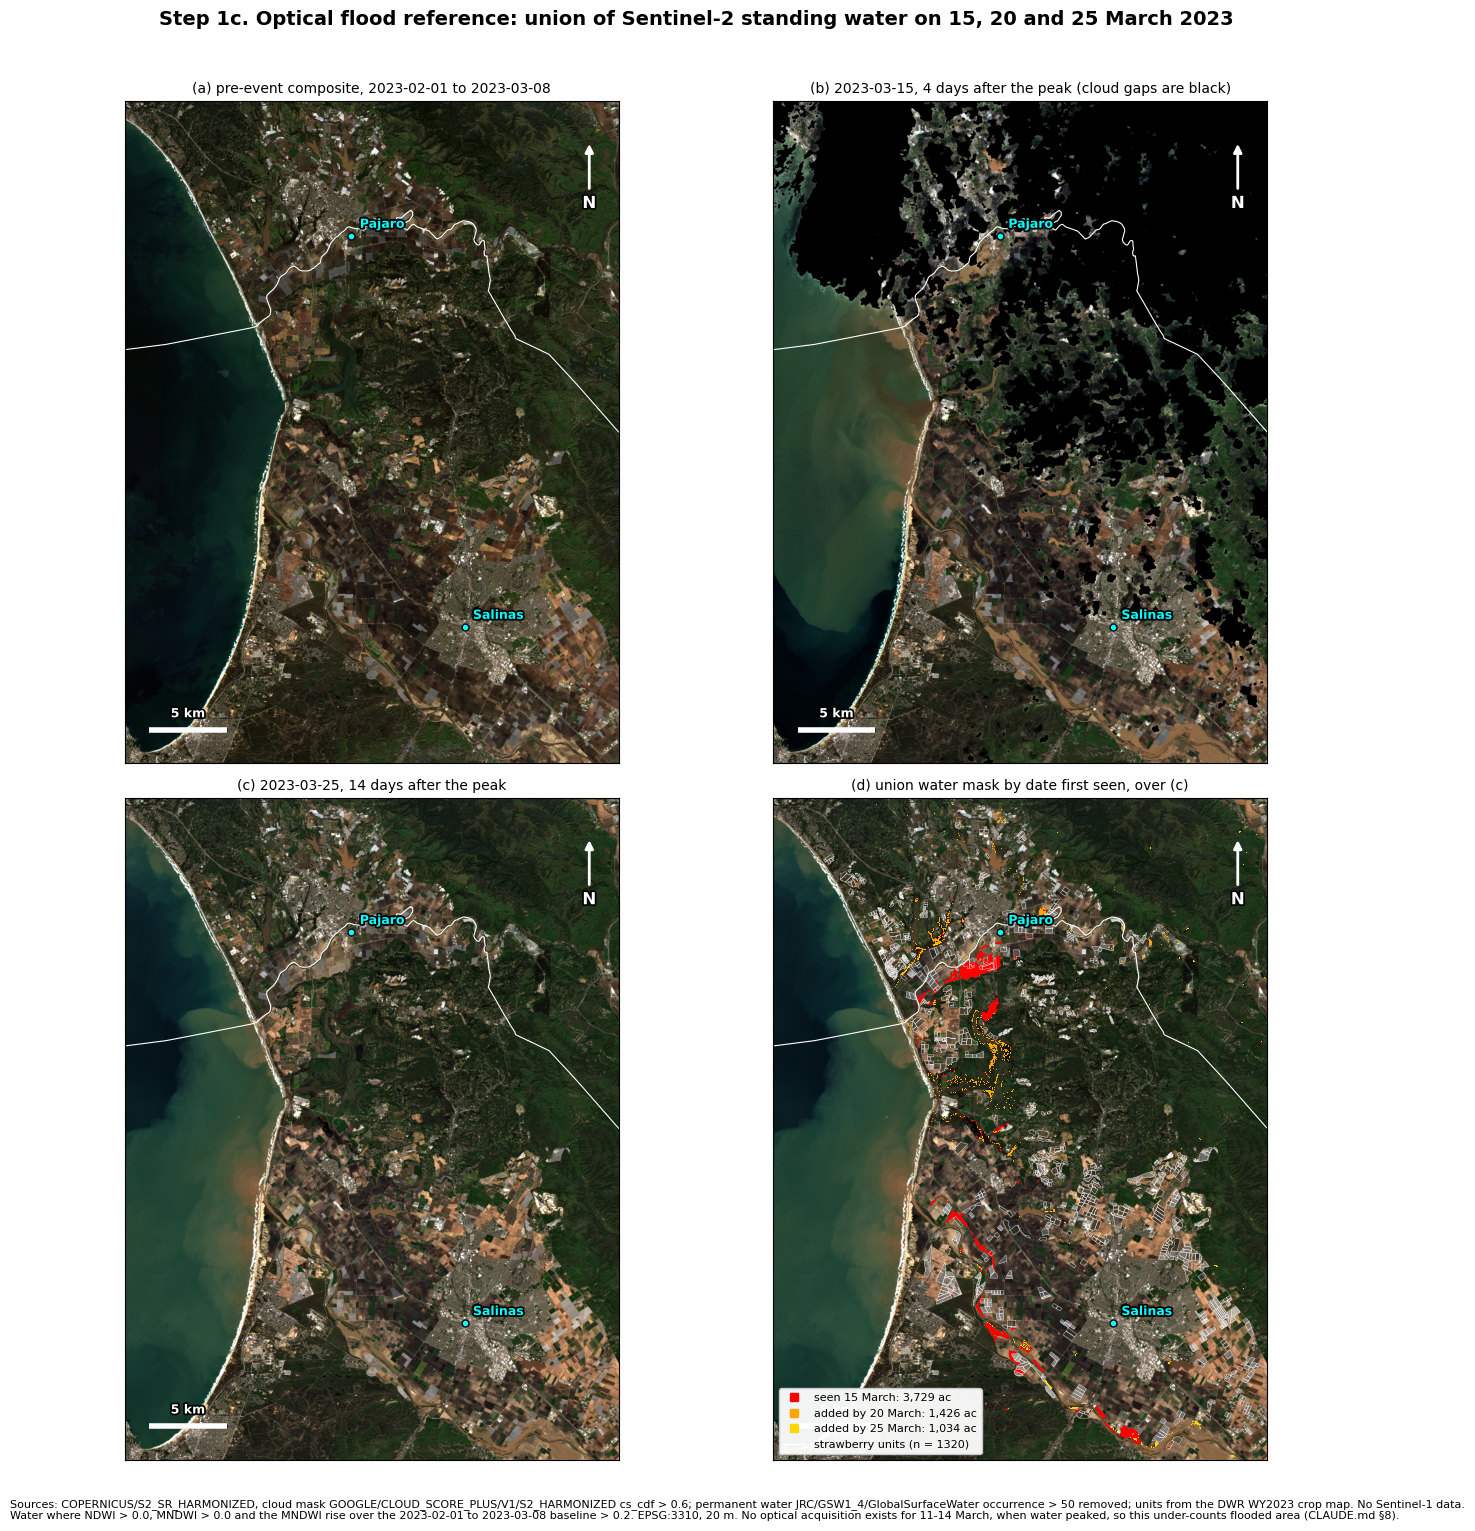

Saved fig_step1c_optical_flood_reference.png | union 6,189 acres
n units = 1320 | date window: post 2023-03-15, 2023-03-20, 2023-03-25; pre 2023-02-01 to 2023-03-08 | datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED (cs_cdf > 0.6), JRC/GSW1_4/GlobalSurfaceWater


In [6]:
VIS = {"bands": ["B4", "B3", "B2"], "min": 0, "max": 0.3}
pre_rgb, ext = ee_tif(clear_s2(*PRE_WINDOW).median().multiply(0.0001).visualize(**VIS),
                      C.DERIVED / "01c_pre_rgb.tif", AOI_LL, 20)
rgb15, _ = ee_tif(clear_s2(d15, next_day(d15)).mosaic().multiply(0.0001).visualize(**VIS),
                  C.DERIVED / "01c_rgb_2023-03-15.tif", AOI_LL, 20)
rgb25, _ = ee_tif(clear_s2(d25, next_day(d25)).mosaic().multiply(0.0001).visualize(**VIS),
                  C.DERIVED / "01c_rgb_2023-03-25.tif", AOI_LL, 20)
seen_arr, _ = ee_tif(seen_code.unmask(0).toByte(), C.DERIVED / "01c_seen_code_20m.tif", AOI_LL, 20)

fig, axes = plt.subplots(2, 2, figsize=(14, 15.5))
panels = [(axes[0, 0], pre_rgb, f"(a) pre-event composite, {PRE_WINDOW[0]} to 2023-03-08"),
          (axes[0, 1], rgb15, f"(b) {d15}, 4 days after the peak (cloud gaps are black)"),
          (axes[1, 0], rgb25, f"(c) {d25}, 14 days after the peak"),
          (axes[1, 1], rgb25, "(d) union water mask by date first seen, over (c)")]
for ax, rgb, title in panels:
    ax.imshow(rgb, extent=ext, origin="upper")
    counties_m.boundary.plot(ax=ax, color="white", lw=0.8)
    for _, t in towns.iterrows():
        ax.plot(t.geometry.x, t.geometry.y, marker="o", ms=5, color="cyan", mec="black")
        ax.annotate(t["name"], (t.geometry.x, t.geometry.y), xytext=(6, 6), textcoords="offset points",
                    color="cyan", fontsize=9, fontweight="bold", path_effects=HALO)
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    add_scale_bar(ax, 5)
    add_north_arrow(ax)

d = axes[1, 1]
d.imshow(np.ma.masked_equal(seen_arr, 0), extent=ext, origin="upper", vmin=1, vmax=3,
         cmap=ListedColormap([SEEN_COLOR[x] for x in DATES]), interpolation="nearest")
units.to_crs(C.GRID_CRS).boundary.plot(ax=d, color="white", lw=0.3, alpha=0.85)
for date_, label in zip(DATES, ["seen 15 March", "added by 20 March", "added by 25 March"]):
    d.plot([], [], "s", color=SEEN_COLOR[date_], label=f"{label}: {nested.loc[nested.date == date_, 'acres'].iloc[0]:,.0f} ac")
d.plot([], [], color="white", lw=1, label=f"strawberry units (n = {N_UNITS})")
d.legend(loc="lower left", fontsize=8, framealpha=0.95)

fig.suptitle("Step 1c. Optical flood reference: union of Sentinel-2 standing water on 15, 20 and 25 "
             "March 2023", fontsize=14, fontweight="bold")
fig.text(0.01, 0.005,
         f"Sources: {C.S2}, cloud mask {C.S2_CLOUD} cs_cdf > {C.CLEAR_CS_CDF}; permanent water {C.GSW} "
         f"occurrence > {C.PERMANENT_WATER} removed; units from the DWR WY2023 crop map. No Sentinel-1 data.\n"
         f"Water where NDWI > {NDWI_MIN}, MNDWI > {MNDWI_MIN} and the MNDWI rise over the "
         f"{PRE_WINDOW[0]} to 2023-03-08 baseline > {D_MNDWI_MIN}. EPSG:3310, 20 m. No optical acquisition "
         "exists for 11-14 March, when water peaked, so this under-counts flooded area (CLAUDE.md §8).",
         fontsize=8, va="bottom")
fig.tight_layout(rect=(0, 0.035, 1, 0.965))
FIG = C.FIGURES / "fig_step1c_optical_flood_reference.png"
fig.savefig(FIG, dpi=200)
plt.show()
print(f"Saved {FIG.name} | union {nested.loc[nested.extent == 'UNION (reference)', 'acres'].iloc[0]:,.0f} acres")
stamp(f"post {', '.join(DATES)}; pre {PRE_WINDOW[0]} to 2023-03-08")